# Klasifikasi Berita Menggunakan Skip-gram dan Naive Bayes

## Pencarian dan Penambangan Web

Notebook ini merupakan lanjutan dari tugas sebelumnya.

Pada tugas sebelumnya, berita direpresentasikan menggunakan TF-IDF, ICSDF,
dan PCA. Pada tugas ini, representasi teks diganti menggunakan metode
Word2Vec Skip-gram dan klasifikasi dilakukan menggunakan Naive Bayes.

### Alur proses

Dataset berita
↓
Preprocessing
↓
Pembagian Training dan Testing
↓
Tokenisasi
↓
Skip-gram
↓
Word Embedding
↓
Vektor setiap berita
↓
Naive Bayes
↓
Prediksi
↓
Evaluasi

### Ketentuan preprocessing

Preprocessing pada tugas ini hanya menghilangkan tanda baca.

Tidak dilakukan:
- Stopword removal
- Stemming
- Normalisasi kata
- Translasi bahasa asing
- TF-IDF
- ICSDF
- PCA

## 1. Install Library

Library yang digunakan pada tugas ini adalah:

- pandas untuk membaca dan mengolah dataset
- numpy untuk operasi numerik
- gensim untuk Word2Vec Skip-gram
- scikit-learn untuk pembagian data dan Naive Bayes
- matplotlib dan seaborn untuk visualisasi evaluasi
- openpyxl untuk membaca dan menyimpan file Excel

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 2. Import Library

Tahap ini digunakan untuk memanggil library yang diperlukan dalam proses
preprocessing, pembentukan Skip-gram, klasifikasi Naive Bayes, dan evaluasi.

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from IPython.display import display

## 3. Membaca Dataset

Dataset yang digunakan merupakan dataset berita yang sama dengan tugas
sebelumnya.

Dataset terdiri dari 200 berita dengan dua kategori:
- sport
- finance

Kolom yang digunakan:
- id
- isi_berita
- label

In [3]:
# Sesuaikan nama file dengan dataset yang kamu punya
FILE_DATASET = "dataset_detik_200_berita.xlsx"

df = pd.read_excel(FILE_DATASET)

print("Jumlah data :", len(df))
print("Nama kolom  :", df.columns.tolist())

display(df.head())

Jumlah data : 200
Nama kolom  : ['id', 'isi_berita', 'label']


,id,isi_berita,label
0,1,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",sport
1,2,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",sport
2,3,Di tengah viral insiden cepirit pada ajang Hyr...,sport
3,4,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,sport
4,5,Bagas Maulana/Apriyani Rahayu tak minder meski...,sport


## 4. Pemeriksaan Dataset

Sebelum melakukan preprocessing, dataset diperiksa untuk mengetahui
struktur data dan memastikan tidak terdapat nilai kosong pada kolom utama.

In [5]:
print("Informasi dataset:")
df.info()

print("\nJumlah nilai kosong:")
print(df[["id", "isi_berita", "label"]].isnull().sum())

print("\nDistribusi label:")
print(df["label"].value_counts())

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   isi_berita  200 non-null    str  
 2   label       200 non-null    str  
dtypes: int64(1), str(2)
memory usage: 4.8 KB

Jumlah nilai kosong:
id            0
isi_berita    0
label         0
dtype: int64

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64


## 5. Mengubah Label Menjadi Numerik

Label berita diubah menjadi bentuk numerik agar dapat digunakan oleh
algoritma klasifikasi.

Mapping yang digunakan:

- finance = 0
- sport = 1

In [8]:
df["label_num"] = df["label"].map({
    "finance": 0,
    "sport": 1
})

print("Mapping label:")
print("finance = 0")
print("sport   = 1")

print("\nDistribusi label numerik:")
print(df["label_num"].value_counts().sort_index())

display(
    df[["id", "label", "label_num"]].head()
)

Mapping label:
finance = 0
sport   = 1

Distribusi label numerik:
label_num
0    100
1    100
Name: count, dtype: int64


,id,label,label_num
0,1,sport,1
1,2,sport,1
2,3,sport,1
3,4,sport,1
4,5,sport,1


## 6. Menghitung Jumlah Kata Sebelum Preprocessing

Jumlah kata dihitung sebelum preprocessing untuk mengetahui kondisi awal
dataset.

In [9]:
df["jumlah_kata_asli"] = (
    df["isi_berita"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(
    "Total seluruh kata:",
    df["jumlah_kata_asli"].sum()
)

print("\nStatistik jumlah kata:")
print(df["jumlah_kata_asli"].describe())

display(
    df[
        ["id", "label", "jumlah_kata_asli"]
    ].head()
)

Total seluruh kata: 67076

Statistik jumlah kata:
count    200.000000
mean     335.380000
std      161.031304
min       42.000000
25%      241.000000
50%      303.000000
75%      392.250000
max      963.000000
Name: jumlah_kata_asli, dtype: float64


,id,label,jumlah_kata_asli
0,1,sport,320
1,2,sport,323
2,3,sport,256
3,4,sport,238
4,5,sport,402


## 7. Preprocessing

Pada tugas ini preprocessing dilakukan dengan hanya menghilangkan tanda baca.

Tidak dilakukan:
- Stopword removal
- Stemming
- Normalisasi kata tidak baku
- Translasi kata asing
- TF-IDF
- ICSDF
- PCA

In [10]:
def remove_punctuation(text):
    text = str(text)

    text = "".join(
        char
        for char in text
        if not unicodedata.category(char).startswith("P")
    )

    text = re.sub(r"\s+", " ", text).strip()

    return text


df["berita_clean"] = df["isi_berita"].apply(
    remove_punctuation
)

display(
    df[
        ["id", "isi_berita", "berita_clean", "label"]
    ].head()
)

,id,isi_berita,berita_clean,label
0,1,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",Dalam dua seri terakhir MotoGP 2027 Marc Marqu...,sport
1,2,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",Alwi Farhan Moh Zaki Ubaidillah dan Muhamad Yu...,sport
2,3,Di tengah viral insiden cepirit pada ajang Hyr...,Di tengah viral insiden cepirit pada ajang Hyr...,sport
3,4,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,Dejan FedinansyahFelisha Alberta Nathaniel Pas...,sport
4,5,Bagas Maulana/Apriyani Rahayu tak minder meski...,Bagas MaulanaApriyani Rahayu tak minder meski ...,sport


## 8. Pemeriksaan Hasil Preprocessing

Beberapa data ditampilkan untuk melihat perbedaan teks sebelum dan
sesudah tanda baca dihilangkan.

In [11]:
for i in range(min(5, len(df))):

    print(f"DATA {i + 1}")
    print("Sebelum:")
    print(df.loc[i, "isi_berita"])

    print("\nSesudah:")
    print(df.loc[i, "berita_clean"])

    print("-" * 100)

DATA 1
Sebelum:
Dalam dua seri terakhir MotoGP 2027, Marc Marquez sukses sapu bersih poin maksimal. Penampilan rider Ducati itu membuat pengamat MotoGP Carlo Pernat menyebutnya seperti makhluk dari Mars. Marquez menyapu bersih MotoGP San Marino di Misano. Ia meraih kemenangan pada Sprint Race dan balapan utama sehingga mengamankan 37 poin dalam satu akhir pekan. Hasil tersebut melanjutkan performa apik Marquez pada seri sebelumnya, ketika meraih 37 poin di MotoGP Aragon. Artinya, Marc mengumpulkan 74 poin maksimal dalam dua seri beruntun. Bagi Pernat, yang membuat Marquez berbeda bukan sekadar kecepatannya. Gaya balap rider asal Spanyol itu dinilai sudah berubah seiring bertambahnya usia dan pengalaman. Pernat menilai Marquez kini lebih mampu mengendalikan situasi balapan dibandingkan beberapa tahun lalu, tidak lagi terlalu sering mengambil risiko hingga berujung crash. Ia lebih baik dalam membaca kondisi dan mengelola balapan. "Marquez adalah makhluk Mars. Bahkan seiring bertambahnya 

## 9. Menghitung Jumlah Kata Setelah Preprocessing

In [12]:
df["jumlah_kata_clean"] = (
    df["berita_clean"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print(
    "Total kata sebelum preprocessing:",
    df["jumlah_kata_asli"].sum()
)

print(
    "Total kata setelah preprocessing:",
    df["jumlah_kata_clean"].sum()
)

display(
    df[
        [
            "id",
            "jumlah_kata_asli",
            "jumlah_kata_clean",
            "label"
        ]
    ].head()
)

Total kata sebelum preprocessing: 67076
Total kata setelah preprocessing: 66885


,id,jumlah_kata_asli,jumlah_kata_clean,label
0,1,320,320,sport
1,2,323,323,sport
2,3,256,256,sport
3,4,238,238,sport
4,5,402,402,sport


## 10. Membagi Data Training dan Testing

Dataset dibagi menjadi:
- 160 data training
- 40 data testing

Pembagian dilakukan secara stratified agar distribusi kelas tetap seimbang.

In [13]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["berita_clean"],
    df["label_num"],
    test_size=40,
    random_state=42,
    stratify=df["label_num"]
)

print("Jumlah training :", len(X_train_text))
print("Jumlah testing  :", len(X_test_text))

print("\nDistribusi TRAINING:")
print(
    y_train.value_counts().sort_index()
)

print("\nDistribusi TESTING:")
print(
    y_test.value_counts().sort_index()
)

Jumlah training : 160
Jumlah testing  : 40

Distribusi TRAINING:
label_num
0    80
1    80
Name: count, dtype: int64

Distribusi TESTING:
label_num
0    20
1    20
Name: count, dtype: int64


## 11. Tokenisasi

Pada tahap ini setiap berita diubah menjadi kumpulan token atau kata.

Tokenisasi dilakukan menggunakan metode `split()` setelah proses
penghapusan tanda baca.

Contoh:

"saya suka makan nasi"

menjadi:

["saya", "suka", "makan", "nasi"]

In [14]:
train_sentences = [
    text.split()
    for text in X_train_text
]

test_sentences = [
    text.split()
    for text in X_test_text
]

print("Contoh tokenisasi TRAINING:")

for i in range(min(3, len(train_sentences))):
    print(f"{i + 1}.", train_sentences[i])

print("\nContoh tokenisasi TESTING:")

for i in range(min(3, len(test_sentences))):
    print(f"{i + 1}.", test_sentences[i])

Contoh tokenisasi TRAINING:
1. ['Mantan', 'Menteri', 'Keuangan', 'Purbaya', 'Yudhi', 'Sadewa', 'menegaskan', 'seluruh', 'urusan', 'yang', 'berkaitan', 'dengan', 'kesepakatan', 'peralihan', 'handover', 'serta', 'penanganan', 'utang', 'proyek', 'Kereta', 'Cepat', 'JakartaBandung', 'Whoosh', 'kini', 'sepenuhnya', 'diserahkan', 'kepada', 'Bendahara', 'Negara', 'yang', 'baru', 'Suahasil', 'Nazara', 'Purbaya', 'menyatakan', 'dengan', 'pencopotannya', 'seluruh', 'rangkaian', 'rencana', 'yang', 'sempat', 'ia', 'rancang', 'terkait', 'peralihan', 'utang', 'Whoosh', 'ke', 'Kementerian', 'Keuangan', 'otomatis', 'menjadi', 'tanggung', 'jawab', 'Suahasil', 'selaku', 'Menkeu', 'selanjutnya', 'Nanti', 'tergantung', 'menteri', 'yang', 'baru', 'lah', 'ujar', 'Purbaya', 'saat', 'ditemui', 'awak', 'media', 'usai', 'acara', 'serah', 'terima', 'jabatan', 'Menkeu', 'kepada', 'Suahasil', 'di', 'Kantor', 'Kemenkeu', 'Jakarta', 'Pusat', 'Selasa', '1592026', 'kemarin', 'Purbaya', 'pun', 'mengaku', 'lega', 'setel

## 12. Membuat Pasangan Target dan Context

Skip-gram mempelajari hubungan antara kata target dan kata-kata
di sekitarnya sebagai context.

Pada tugas ini digunakan `window_size = 1`.

Artinya setiap kata akan melihat satu kata di sebelah kiri dan satu kata
di sebelah kanan apabila tersedia.

Contoh:

["saya", "suka", "makan"]

Pasangan target-context:

saya → suka
suka → saya
suka → makan
makan → suka

In [15]:
WINDOW_SIZE = 1

training_pairs = []

for sentence in train_sentences:

    for i, target_word in enumerate(sentence):

        start = max(
            0,
            i - WINDOW_SIZE
        )

        end = min(
            len(sentence),
            i + WINDOW_SIZE + 1
        )

        for j in range(start, end):

            if i != j:

                context_word = sentence[j]

                training_pairs.append(
                    (target_word, context_word)
                )

print(
    "Jumlah pasangan target-context:",
    len(training_pairs)
)

print("\n20 pasangan pertama:")

for pair in training_pairs[:20]:
    print(pair[0], "→", pair[1])

Jumlah pasangan target-context: 105964

20 pasangan pertama:
Mantan → Menteri
Menteri → Mantan
Menteri → Keuangan
Keuangan → Menteri
Keuangan → Purbaya
Purbaya → Keuangan
Purbaya → Yudhi
Yudhi → Purbaya
Yudhi → Sadewa
Sadewa → Yudhi
Sadewa → menegaskan
menegaskan → Sadewa
menegaskan → seluruh
seluruh → menegaskan
seluruh → urusan
urusan → seluruh
urusan → yang
yang → urusan
yang → berkaitan
berkaitan → yang


## 13. Membuat Vocabulary

Vocabulary dibentuk berdasarkan seluruh kata yang terdapat pada data
training.

Setiap kata diberikan indeks numerik agar dapat digunakan dalam proses
training Skip-gram.

Vocabulary hanya dibuat dari data training.

In [16]:
vocabulary = sorted({
    word
    for sentence in train_sentences
    for word in sentence
})

word_to_index = {
    word: i
    for i, word in enumerate(vocabulary)
}

index_to_word = {
    i: word
    for word, i in word_to_index.items()
}

VOCAB_SIZE = len(vocabulary)

print(
    "Jumlah vocabulary:",
    VOCAB_SIZE
)

print("\nContoh vocabulary:")

for word in vocabulary[:30]:
    print(
        word,
        "→",
        word_to_index[word]
    )

Jumlah vocabulary: 8282

Contoh vocabulary:
+0657s → 0
+110kg → 1
+14021s → 2
+18252s → 3
+20581s → 4
+20858s → 5
+22911s → 6
+23229s → 7
+2326s → 8
+23905s → 9
+28031s → 10
+28927s → 11
+31792s → 12
+6027s → 13
+86kg → 14
0 → 15
001 → 16
004 → 17
006 → 18
0060 → 19
010 → 20
0103 → 21
012 → 22
013 → 23
0133 → 24
019 → 25
02 → 26
023 → 27
024 → 28
0262030 → 29


## 14. Parameter Skip-gram

Skip-gram akan digunakan untuk mempelajari representasi vektor setiap
kata berdasarkan pasangan target-context.

Parameter yang digunakan:

- Vector size = 50
- Window size = 1
- Learning rate = 0.025
- Epoch = 5
- Random seed = 42

In [17]:
VECTOR_SIZE = 50
LEARNING_RATE = 0.025
EPOCHS = 5

print("Vector size   :", VECTOR_SIZE)
print("Window size   :", WINDOW_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Epoch         :", EPOCHS)
print("Vocabulary    :", VOCAB_SIZE)

Vector size   : 50
Window size   : 1
Learning rate : 0.025
Epoch         : 5
Vocabulary    : 8282


## 15. Fungsi Softmax

Softmax digunakan untuk mengubah nilai output model menjadi probabilitas
untuk setiap kata dalam vocabulary.

In [18]:
def softmax(x):

    x = x - np.max(x)

    exp_x = np.exp(x)

    return exp_x / np.sum(exp_x)

## 16. Inisialisasi Bobot Skip-gram

Model Skip-gram menggunakan dua matriks bobot:

- W1 sebagai representasi embedding kata
- W2 sebagai bobot output

Bobot diinisialisasi menggunakan nilai acak kecil.

In [19]:
np.random.seed(42)

W1 = (
    np.random.randn(
        VOCAB_SIZE,
        VECTOR_SIZE
    ) * 0.01
)

W2 = (
    np.random.randn(
        VECTOR_SIZE,
        VOCAB_SIZE
    ) * 0.01
)

print(
    "Shape W1:",
    W1.shape
)

print(
    "Shape W2:",
    W2.shape
)

Shape W1: (8282, 50)
Shape W2: (50, 8282)


## 16. Training Skip-gram

Training dilakukan menggunakan pasangan target-context yang telah dibuat.

Untuk setiap pasangan:

Target → Context

model melakukan:

1. Mengambil embedding kata target.
2. Menghitung output terhadap seluruh vocabulary.
3. Menggunakan softmax untuk memperoleh probabilitas.
4. Menghitung loss.
5. Menghitung gradient.
6. Memperbarui bobot W1 dan W2.

Embedding pada W1 akan digunakan sebagai representasi vektor kata.

In [20]:
for epoch in range(EPOCHS):

    total_loss = 0

    for target_word, context_word in training_pairs:

        target_idx = word_to_index[target_word]
        context_idx = word_to_index[context_word]

        # Embedding kata target
        hidden = W1[target_idx]

        # Forward pass
        output = np.dot(
            hidden,
            W2
        )

        # Probabilitas context
        probabilities = softmax(
            output
        )

        # Cross entropy loss
        loss = -np.log(
            probabilities[context_idx] + 1e-10
        )

        total_loss += loss

        # Error output
        error = probabilities.copy()

        error[context_idx] -= 1

        # Gradient W2
        grad_W2 = np.outer(
            hidden,
            error
        )

        # Gradient hidden layer
        grad_hidden = np.dot(
            W2,
            error
        )

        # Update W2
        W2 -= (
            LEARNING_RATE *
            grad_W2
        )

        # Update W1
        W1[target_idx] -= (
            LEARNING_RATE *
            grad_hidden
        )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {total_loss:.4f}"
    )

Epoch 1/5 - Loss: 955226.0042
Epoch 2/5 - Loss: 905247.5423
Epoch 3/5 - Loss: 833572.3770
Epoch 4/5 - Loss: 794387.2571
Epoch 5/5 - Loss: 766271.2058


## 17. Word Embedding Hasil Skip-gram

Setelah proses training selesai, matriks W1 digunakan sebagai word
embedding.

Setiap baris pada W1 merupakan representasi vektor untuk satu kata
dalam vocabulary.

In [21]:
word_embeddings = W1

print(
    "Shape word embedding:",
    word_embeddings.shape
)

Shape word embedding: (8282, 50)


## 18. Melihat Vektor Kata

Bagian ini digunakan untuk melihat hasil representasi numerik dari kata
setelah training Skip-gram.

In [22]:
embedding_rows = []

for word in vocabulary:

    idx = word_to_index[word]

    vector = word_embeddings[idx]

    row = {
        "Kata": word
    }

    for i, value in enumerate(
        vector,
        1
    ):

        row[f"Vektor_{i}"] = value

    embedding_rows.append(row)


df_word_embedding = pd.DataFrame(
    embedding_rows
)

display(
    df_word_embedding.head()
)

,Kata,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,...,Vektor_41,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50
0,+0657s,0.007914,-0.000532,0.010025,-0.003380,0.005554,0.007037,0.032875,0.020387,-0.002351,...,0.002061,-0.005817,0.014298,0.010966,-0.006986,-0.038593,-0.004890,-0.001449,0.008807,-0.021135
1,+110kg,-0.076171,0.008515,-0.080365,0.046188,0.025162,0.019898,-0.033949,0.195220,-0.033761,...,0.019456,-0.088965,0.151752,-0.015440,0.031825,-0.327789,0.093255,-0.074397,-0.012363,0.008265
2,+14021s,-0.013366,-0.009513,-0.005762,-0.017156,0.009377,0.013030,0.029653,0.003540,0.006095,...,0.000197,0.012482,-0.012688,0.000187,-0.004948,0.001520,-0.015022,-0.016585,0.002137,0.004938
3,+18252s,0.007794,0.002384,-0.010963,-0.002224,0.006570,-0.002446,0.019471,0.007469,-0.008940,...,-0.003533,0.002829,0.001678,-0.015236,-0.002786,-0.003568,-0.012441,-0.002806,-0.000024,-0.009264
4,+20581s,0.013082,-0.007630,-0.000945,-0.026542,0.014187,0.010436,0.023498,0.024558,0.012892,...,-0.013441,-0.011390,0.025261,0.004373,-0.018995,-0.045088,-0.007747,-0.018211,0.014785,0.003328


In [23]:
kata_contoh = vocabulary[0]

idx = word_to_index[
    kata_contoh
]

print(
    "Kata:",
    kata_contoh
)

print(
    "\nVektor:"
)

print(
    word_embeddings[idx]
)

print(
    "\nDimensi vektor:",
    len(
        word_embeddings[idx]
    )
)

Kata: +0657s

Vektor:
[ 7.91385149e-03 -5.32335194e-04  1.00253789e-02 -3.38003025e-03
  5.55434262e-03  7.03666116e-03  3.28752695e-02  2.03873932e-02
 -2.35081729e-03  1.00865836e-02 -8.77910625e-03  9.88059834e-03
  5.82912570e-03 -1.56967821e-02 -1.49736579e-02  6.08445689e-03
 -6.61750077e-04 -3.96352734e-03 -1.82578409e-02 -3.43305916e-02
 -1.01666427e-02  3.73417957e-03 -9.83950162e-03 -5.37011979e-03
 -5.31548204e-03  4.57414266e-04 -2.44803646e-02  1.35961777e-02
 -9.41327830e-04 -1.38027454e-02 -1.35604103e-02  3.98211396e-02
  2.12425340e-02  6.91598621e-03  1.09804473e-02  2.80735460e-03
 -8.94241341e-05 -3.30362154e-03 -1.76806873e-02  3.56249253e-03
  2.06118458e-03 -5.81685958e-03  1.42977436e-02  1.09660776e-02
 -6.98587014e-03 -3.85927019e-02 -4.88955436e-03 -1.44869940e-03
  8.80662829e-03 -2.11350720e-02]

Dimensi vektor: 50


## 19. Mengubah Berita Menjadi Vektor

Skip-gram menghasilkan vektor untuk setiap kata.

Namun Naive Bayes membutuhkan satu baris fitur untuk setiap berita.

Oleh karena itu, setiap berita direpresentasikan menggunakan rata-rata
seluruh word embedding yang terdapat dalam berita.

Rumus:

Vektor Berita =
rata-rata seluruh Vektor Kata dalam berita

In [24]:
def document_vector(
    tokens,
    word_to_index,
    embeddings,
    vector_size
):

    vectors = []

    for word in tokens:

        if word in word_to_index:

            idx = word_to_index[word]

            vectors.append(
                embeddings[idx]
            )

    if len(vectors) == 0:

        return np.zeros(
            vector_size
        )

    return np.mean(
        vectors,
        axis=0
    )

In [25]:
X_train_vectors = np.vstack([

    document_vector(
        tokens,
        word_to_index,
        word_embeddings,
        VECTOR_SIZE
    )

    for tokens in train_sentences
])

print(
    "Shape X_train_vectors:",
    X_train_vectors.shape
)

Shape X_train_vectors: (160, 50)


In [26]:
X_test_vectors = np.vstack([

    document_vector(
        tokens,
        word_to_index,
        word_embeddings,
        VECTOR_SIZE
    )

    for tokens in test_sentences
])

print(
    "Shape X_test_vectors:",
    X_test_vectors.shape
)

Shape X_test_vectors: (40, 50)


## 20. Dataset Vektor Training

Dataset training terdiri dari 160 berita dengan 50 fitur hasil
representasi Skip-gram dan satu kolom label.

In [27]:
vector_columns = [
    f"Vektor_{i}"
    for i in range(
        1,
        VECTOR_SIZE + 1
    )
]

df_train_vectors = pd.DataFrame(
    X_train_vectors,
    columns=vector_columns
)

df_train_vectors["label"] = (
    y_train.reset_index(
        drop=True
    )
)

print(
    "Shape training:",
    df_train_vectors.shape
)

display(
    df_train_vectors.head()
)

Shape training: (160, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,-0.054823,-0.032495,-0.031093,-0.331313,0.225695,0.123297,0.078394,0.251283,0.051698,0.197676,...,-0.002199,0.038643,0.121907,0.019692,-0.331770,0.130890,-0.056316,0.016299,0.014920,0
1,-0.119748,0.058347,-0.029582,-0.290773,0.336915,0.106530,0.095110,0.247536,0.020339,0.156473,...,-0.043277,0.151517,0.144229,0.064033,-0.437212,0.205927,-0.041117,0.046477,0.117999,1
2,-0.106445,0.043761,0.008277,-0.265117,0.217238,0.165161,0.085318,0.181989,-0.000360,0.158393,...,-0.000396,0.115831,0.133047,0.032050,-0.340983,0.126526,-0.045640,0.020458,0.032326,0
3,-0.088335,0.023164,-0.026936,-0.282686,0.278973,0.146816,0.131700,0.215119,0.050025,0.131699,...,-0.083315,0.157228,0.123633,0.038231,-0.474326,0.186725,-0.012462,0.007737,0.064194,1
4,-0.025734,-0.051660,-0.096194,-0.274681,0.326999,0.175491,0.170080,0.234900,0.134387,0.167120,...,-0.093969,0.103888,0.026114,-0.070000,-0.528392,0.116426,-0.063753,-0.024386,0.051570,1


## 21. Dataset Vektor Testing

Dataset testing terdiri dari 40 berita dengan 50 fitur hasil Skip-gram
dan satu kolom label.

In [28]:
df_test_vectors = pd.DataFrame(
    X_test_vectors,
    columns=vector_columns
)

df_test_vectors["label"] = (
    y_test.reset_index(
        drop=True
    )
)

print(
    "Shape testing:",
    df_test_vectors.shape
)

display(
    df_test_vectors.head()
)

Shape testing: (40, 51)


,Vektor_1,Vektor_2,Vektor_3,Vektor_4,Vektor_5,Vektor_6,Vektor_7,Vektor_8,Vektor_9,Vektor_10,...,Vektor_42,Vektor_43,Vektor_44,Vektor_45,Vektor_46,Vektor_47,Vektor_48,Vektor_49,Vektor_50,label
0,0.119211,-0.034747,-0.085975,-0.245587,0.229738,0.188090,0.097475,0.240311,0.100461,0.314398,...,-0.018116,0.050981,0.057102,-0.033455,-0.397459,0.008689,-0.067464,0.001357,0.028123,0
1,-0.041866,-0.001580,-0.059807,-0.224029,0.382680,0.054031,0.208569,0.368166,0.133023,0.148906,...,-0.155748,0.184679,0.029180,-0.000673,-0.525233,0.158024,-0.132602,0.066705,0.100421,1
2,-0.127273,0.062186,0.005373,-0.237436,0.171574,0.201837,0.150173,0.158603,0.021413,0.099133,...,0.002158,0.154947,0.159767,0.050363,-0.422303,0.128996,0.043445,0.047663,0.012126,1
3,-0.091535,0.049017,-0.087239,-0.287269,0.384729,0.135533,0.071108,0.288761,0.056773,0.113961,...,-0.099640,0.127737,0.161501,0.039399,-0.424348,0.123913,-0.058580,0.035205,0.019324,1
4,0.001422,0.027191,-0.095612,-0.300512,0.321131,0.137810,0.110292,0.271102,0.094165,0.247625,...,-0.007389,0.095506,0.148821,0.038951,-0.404077,0.073986,-0.042435,0.054257,0.047655,0


## 22. Menyimpan Hasil Vektor Skip-gram

In [29]:
df_train_vectors.to_excel(
    "data_skipgram_training.xlsx",
    index=False
)

df_test_vectors.to_excel(
    "data_skipgram_testing.xlsx",
    index=False
)

print(
    "Data berhasil disimpan:"
)

print(
    "data_skipgram_training.xlsx"
)

print(
    "data_skipgram_testing.xlsx"
)

Data berhasil disimpan:
data_skipgram_training.xlsx
data_skipgram_testing.xlsx


## 23. Menyiapkan Data untuk Naive Bayes

Vektor hasil Skip-gram digunakan sebagai fitur input untuk algoritma
Gaussian Naive Bayes.

X berisi fitur vektor Skip-gram.

y berisi label berita:
- 0 = finance
- 1 = sport

In [30]:
X_train_nb = (
    df_train_vectors
    .drop(
        columns=["label"]
    )
    .to_numpy()
)

X_test_nb = (
    df_test_vectors
    .drop(
        columns=["label"]
    )
    .to_numpy()
)

y_train_nb = (
    df_train_vectors["label"]
    .to_numpy()
)

y_test_nb = (
    df_test_vectors["label"]
    .to_numpy()
)

print(
    "X_train:",
    X_train_nb.shape
)

print(
    "X_test :",
    X_test_nb.shape
)

print(
    "y_train:",
    y_train_nb.shape
)

print(
    "y_test :",
    y_test_nb.shape
)

X_train: (160, 50)
X_test : (40, 50)
y_train: (160,)
y_test : (40,)


## 24. Training Gaussian Naive Bayes

Gaussian Naive Bayes digunakan untuk melakukan klasifikasi berdasarkan
vektor Skip-gram yang telah diperoleh sebelumnya.

In [31]:
nb_model = GaussianNB()

nb_model.fit(
    X_train_nb,
    y_train_nb
)

print(
    "Gaussian Naive Bayes berhasil dilatih."
)

Gaussian Naive Bayes berhasil dilatih.


## 25. Prediksi Data Testing

In [32]:
y_pred = nb_model.predict(
    X_test_nb
)

df_hasil_prediksi = pd.DataFrame({

    "Data_Testing": np.arange(
        1,
        len(y_test_nb) + 1
    ),

    "Label_Aktual": y_test_nb,

    "Label_Prediksi": y_pred
})

df_hasil_prediksi["Status"] = np.where(

    df_hasil_prediksi["Label_Aktual"]
    ==
    df_hasil_prediksi["Label_Prediksi"],

    "Benar",

    "Salah"
)

display(
    df_hasil_prediksi
)

,Data_Testing,Label_Aktual,Label_Prediksi,Status
0,1,0,0,Benar
1,2,1,1,Benar
2,3,1,0,Salah
3,4,1,1,Benar
4,5,0,0,Benar
5,6,1,0,Salah
6,7,0,0,Benar
7,8,1,0,Salah
8,9,1,1,Benar
9,10,0,1,Salah


## 26. Evaluasi Accuracy

In [33]:
accuracy = accuracy_score(
    y_test_nb,
    y_pred
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

Accuracy : 0.8750
Accuracy : 87.50%


## 27. Precision, Recall, dan F1-Score

In [34]:
precision = precision_score(
    y_test_nb,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test_nb,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test_nb,
    y_pred,
    average="macro",
    zero_division=0
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1-Score  : {f1:.4f}"
)

Precision : 0.8836
Recall    : 0.8750
F1-Score  : 0.8743


In [35]:
print(
    classification_report(
        y_test_nb,
        y_pred,
        target_names=[
            "finance",
            "sport"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     finance       0.83      0.95      0.88        20
       sport       0.94      0.80      0.86        20

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.87        40



## 28. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah
untuk masing-masing kelas.

In [36]:
cm = confusion_matrix(
    y_test_nb,
    y_pred,
    labels=[0, 1]
)

print(
    "Confusion Matrix:"
)

print(cm)

Confusion Matrix:
[[19  1]
 [ 4 16]]


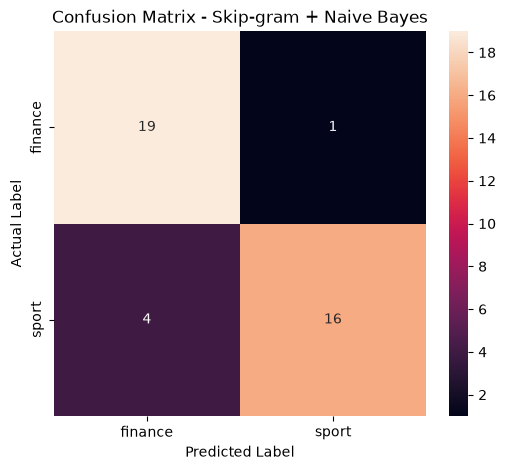

In [37]:
plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "finance",
        "sport"
    ],
    yticklabels=[
        "finance",
        "sport"
    ]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    "Confusion Matrix - Skip-gram + Naive Bayes"
)

plt.show()

In [38]:
df_salah = df_hasil_prediksi[
    df_hasil_prediksi["Status"]
    == "Salah"
]

print(
    "Jumlah prediksi salah:",
    len(df_salah)
)

display(
    df_salah
)

Jumlah prediksi salah: 5


,Data_Testing,Label_Aktual,Label_Prediksi,Status
2,3,1,0,Salah
5,6,1,0,Salah
7,8,1,0,Salah
9,10,0,1,Salah
21,22,1,0,Salah


## 29. Ringkasan Hasil Evaluasi

In [39]:
df_evaluasi = pd.DataFrame({

    "Model": [
        "Skip-gram + Naive Bayes"
    ],

    "Jumlah_Training": [
        len(y_train_nb)
    ],

    "Jumlah_Testing": [
        len(y_test_nb)
    ],

    "Vector_Size": [
        VECTOR_SIZE
    ],

    "Window": [
        WINDOW_SIZE
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision_Macro": [
        precision
    ],

    "Recall_Macro": [
        recall
    ],

    "F1_Macro": [
        f1
    ]
})

display(
    df_evaluasi
)

,Model,Jumlah_Training,Jumlah_Testing,Vector_Size,Window,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,Skip-gram + Naive Bayes,160,40,50,1,0.875,0.883632,0.875,0.874293


In [40]:
df_hasil_prediksi.to_excel(
    "hasil_prediksi_skipgram_naive_bayes.xlsx",
    index=False
)

df_evaluasi.to_excel(
    "evaluasi_skipgram_naive_bayes.xlsx",
    index=False
)

print(
    "Semua hasil berhasil disimpan."
)

Semua hasil berhasil disimpan.
